# XGBoost Baseline — Clasificación Multiclase de Incontinencia Urinaria

## Objetivo

Este notebook entrena un modelo XGBoost con parámetros por defecto sobre el dataset procesado por el pipeline de preprocesamiento (`nhanes_clean.csv`). Su propósito no es obtener el mejor modelo posible, sino **establecer una línea base de rendimiento** y, sobre todo, **detectar problemas en los datos antes de optimizar**.

## Estructura del notebook

| Sección | Contenido |
|---|---|
| **1. Setup** | Carga de librerías y datos |
| **2. Encode del target** | Conversión de etiquetas string a enteros |
| **3. Baseline completo** | Entrenamiento con todas las variables |
| **4. Diagnóstico de leakage** | Feature importance y cross-validation |
| **5. Comparación de escenarios** | Con leaky vs sin leaky vs solo demográficas |
| **6. Decisión** | Justificación del camino elegido para el tuning |

> **Nota:** Este notebook documenta el proceso de detección de un problema crítico de *data leakage* que modificó el enfoque del modelado. El notebook de tuning (`04_xgboost.ipynb`) parte de las conclusiones aquí obtenidas.

---
## Sección 1 — Setup

Importamos las librerías necesarias y cargamos los datasets generados por el pipeline de preprocesamiento. Los archivos `X_train_final.csv` y `X_test_final.csv` ya están escalados con `StandardScaler` y balanceados con SMOTE (solo el conjunto de entrenamiento).

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (classification_report, confusion_matrix,
                             f1_score, ConfusionMatrixDisplay)
import joblib
import warnings
warnings.filterwarnings('ignore')

print(f"XGBoost version: {xgb.__version__}")

XGBoost version: 3.2.0


In [ ]:
X_train = pd.read_csv('../data/processed/X_train_scaled.csv')
y_train = pd.read_csv('../data/processed/y_train_scaled.csv').squeeze()
X_test  = pd.read_csv('../data/processed/X_test_scaled.csv')
y_test  = pd.read_csv('../data/processed/y_test.csv').squeeze()

print(f"Train: {X_train.shape} | Test: {X_test.shape}")
print(f"Clases: {y_train.unique()}")

Train: (15540, 23) | Test: (1815, 23)
Clases: <StringArray>
['mixed', 'none', 'urge', 'stress']
Length: 4, dtype: str


---
## Sección 2 — Encode del target

XGBoost requiere que las etiquetas de clase sean números enteros consecutivos (0, 1, 2, 3). Usamos `LabelEncoder` de scikit-learn, que asigna los enteros en orden alfabético:

- `mixed`  → 0  
- `none`   → 1  
- `stress` → 2  
- `urge`   → 3  

Guardamos el encoder en disco para que el pipeline de producción pueda invertir la transformación y devolver etiquetas legibles.

In [3]:
# XGBoost necesita que las clases sean 0,1,2,3 — no strings
le = LabelEncoder()
le.fit(y_train)

y_train_enc = le.transform(y_train)
y_test_enc  = le.transform(y_test)

CLASS_ORDER = le.classes_  # ['mixed', 'none', 'stress', 'urge'] — orden alfabético
print("Mapeo de clases:")
for i, cls in enumerate(CLASS_ORDER):
    print(f"  {cls} → {i}")

# Guardamos el encoder para producción
joblib.dump(le, '../models/label_encoder.pkl')

Mapeo de clases:
  mixed → 0
  none → 1
  stress → 2
  urge → 3


['../models/label_encoder.pkl']

---
## Sección 3 — Modelo baseline (todas las variables)

Entrenamos el primer modelo con los parámetros por defecto de XGBoost y **todas las variables disponibles**, incluyendo las que más adelante identificaremos como problemáticas. El objetivo es tener un punto de referencia numérico antes de cualquier intervención.

Usamos `objective='multi:softprob'` porque queremos probabilidades por clase (no solo la clase ganadora), lo que nos permitirá analizar la confianza del modelo en secciones posteriores.

In [4]:
# Parámetros mínimos para multiclase con XGBoost
xgb_baseline = xgb.XGBClassifier(
    objective='multi:softprob',   # probabilidades por clase
    num_class=4,
    eval_metric='mlogloss',
    use_label_encoder=False,
    random_state=42,
    n_jobs=-1
)

xgb_baseline.fit(
    X_train, y_train_enc,
    eval_set=[(X_test, y_test_enc)],
    verbose=False
)

print("✓ Baseline entrenado")

✓ Baseline entrenado


### 3.1 Métricas del baseline

Evaluamos el modelo sobre el conjunto de test. Las métricas que reportamos son:
- **Precision**: de los que predije como clase X, ¿cuántos lo eran realmente?
- **Recall**: de los que realmente son clase X, ¿cuántos detecté?
- **F1-score**: media armónica de precision y recall. Es la métrica principal por el desbalanceo entre clases.
- **F1-macro**: promedio del F1 por clase sin ponderar por tamaño — penaliza igual un error en `urge` que en `none`.

In [5]:
y_pred = xgb_baseline.predict(X_test)

print("=== CLASSIFICATION REPORT ===")
print(classification_report(y_test_enc, y_pred, target_names=CLASS_ORDER))

f1_macro = f1_score(y_test_enc, y_pred, average='macro')
print(f"F1-macro (línea base): {f1_macro:.4f}")

=== CLASSIFICATION REPORT ===
              precision    recall  f1-score   support

       mixed       0.95      0.96      0.96       328
        none       0.97      0.93      0.95       972
      stress       0.92      0.98      0.95       317
        urge       0.89      0.95      0.92       198

    accuracy                           0.95      1815
   macro avg       0.93      0.96      0.94      1815
weighted avg       0.95      0.95      0.95      1815

F1-macro (línea base): 0.9448


### 3.2 Matriz de confusión

La matriz de confusión muestra, para cada clase real (filas), cómo distribuyó el modelo sus predicciones (columnas). La diagonal principal representa los aciertos. Los valores fuera de la diagonal son errores y nos permiten identificar qué pares de clases se confunden entre sí con más frecuencia.

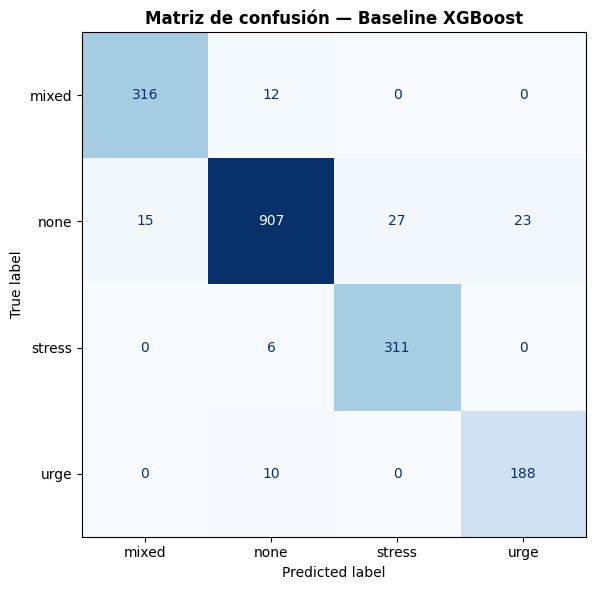

In [6]:
cm = confusion_matrix(y_test_enc, y_pred)
fig, ax = plt.subplots(figsize=(7, 6))
disp = ConfusionMatrixDisplay(cm, display_labels=CLASS_ORDER)
disp.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title('Matriz de confusión — Baseline XGBoost', fontweight='bold')
plt.tight_layout()
plt.savefig('../assets/12_confusion_matrix_baseline.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Sección 4 — Diagnóstico: detección de data leakage

Un F1-macro de ~0.94 en un baseline sin tuning es inusualmente alto. Antes de celebrar el resultado, es necesario investigar si el modelo está **aprendiendo un patrón clínico real** o si está **explotando una relación artificial entre las variables y el target**.

El EDA ya advertía que `ui_esfuerzo_presente` y `ui_urgencia_presente` tienen un Cramér's V = 1.0 con el target. Esto significa que estas dos variables **codifican directamente la regla con la que se construyó el target**: esfuerzo sin urgencia = `stress`, urgencia sin esfuerzo = `urge`, ambas = `mixed`. El modelo no necesita aprender nada — solo leer esas dos columnas.

Esto se conoce como **data leakage**: información que en un escenario real no estaría disponible en el momento de la predicción contamina el entrenamiento y produce métricas artificialmente infladas.

### 4.1 Feature importance

El gráfico de importancia de variables nos muestra qué peso le asignó el modelo a cada feature. Si las variables sospechosas dominan el ranking, confirma el leakage.

Las barras en rojo marcan las variables potencialmente leaky; las azules, el resto.

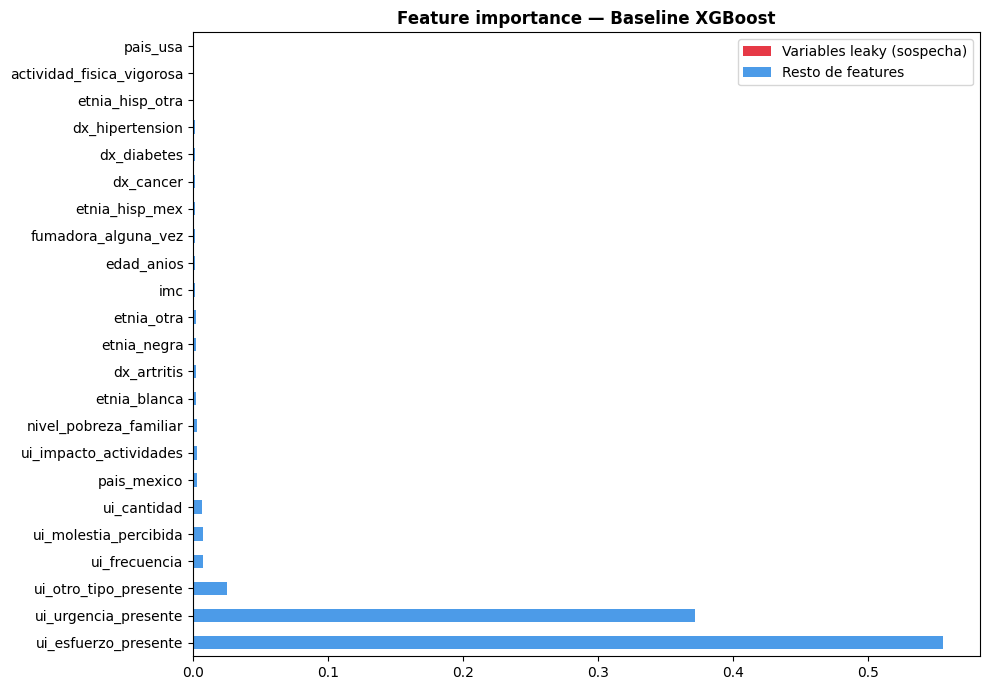

In [7]:
feat_imp = pd.Series(
    xgb_baseline.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 7))
colors = ['#E63946' if 'ui_esfuerzo' in f or 'ui_urgencia' in f 
          else '#4C9BE8' for f in feat_imp.index]
feat_imp.plot(kind='barh', ax=ax, color=colors[::-1])
ax.set_title('Feature importance — Baseline XGBoost', fontweight='bold')
ax.axvline(0, color='black', lw=0.5)

from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='#E63946', label='Variables leaky (sospecha)'),
                   Patch(facecolor='#4C9BE8', label='Resto de features')]
ax.legend(handles=legend_elements)
plt.tight_layout()
plt.savefig('../assets/13_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

### 4.2 Cross-validation estratificada

Validamos el modelo con **StratifiedKFold de 5 folds** para estimar el rendimiento real sobre datos no vistos. La estratificación garantiza que cada fold mantiene la misma proporción de clases que el dataset completo, lo cual es especialmente importante con `urge` (clase minoritaria, ~10%).

Una desviación estándar menor a 0.01 entre folds, combinada con un F1 cercano a 1.0, refuerza la sospecha de leakage: el modelo es demasiado estable porque está aprendiendo una regla trivial, no un patrón que varía naturalmente entre subconjuntos de datos.

> **Nota técnica:** La CV se ejecuta sobre `X_train` **antes de SMOTE**. Aplicar SMOTE fuera del fold introduciría una segunda forma de leakage — muestras sintéticas de validación contaminadas por la distribución del entrenamiento.

In [ ]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

cv_config = joblib.load('../models/cv_config.pkl')
skf = StratifiedKFold(**cv_config)


# OJO: usamos X_train + y_train_enc (ANTES de SMOTE) para CV honesta
# SMOTE solo debe aplicarse dentro de cada fold, no antes
cv_scores = cross_val_score(
    xgb_baseline, X_train, y_train_enc,
    cv=skf, scoring='f1_macro', n_jobs=-1
)

print("Cross-validation F1-macro (5 folds):")
for i, s in enumerate(cv_scores, 1):
    print(f"  Fold {i}: {s:.4f}")
print(f"\nMedia:  {cv_scores.mean():.4f}")
print(f"Std:    {cv_scores.std():.4f}  ← si es <0.01, sospecha leakage")

Cross-validation F1-macro (5 folds):
  Fold 1: 0.9736
  Fold 2: 0.9773
  Fold 3: 0.9800
  Fold 4: 0.9783
  Fold 5: 0.9747

Media:  0.9768
Std:    0.0023  ← si es <0.01, sospecha leakage


### 4.3 Confirmación: modelo sin las variables leaky

La prueba definitiva del leakage es retirar las variables sospechosas y medir cuánto cae el F1. Si la caída es mayor a 0.10, el modelo anterior no era clínicamente válido — su rendimiento dependía casi exclusivamente de información que no debería estar disponible.

| Diferencia de F1 | Diagnóstico |
|---|---|
| < 0.05 | Sin leakage relevante |
| 0.05 – 0.15 | Leakage moderado — evaluar caso a caso |
| > 0.15 | **Leakage grave — las variables deben excluirse** |

In [9]:
leaky_cols = ['ui_esfuerzo_presente', 'ui_urgencia_presente']

X_train_noleak = X_train.drop(columns=leaky_cols)
X_test_noleak  = X_test.drop(columns=leaky_cols)

xgb_noleak = xgb.XGBClassifier(
    objective='multi:softprob', num_class=4,
    eval_metric='mlogloss', use_label_encoder=False,
    random_state=42, n_jobs=-1
)
xgb_noleak.fit(X_train_noleak, y_train_enc, verbose=False)

y_pred_noleak = xgb_noleak.predict(X_test_noleak)
f1_noleak = f1_score(y_test_enc, y_pred_noleak, average='macro')

print(f"F1-macro CON variables leaky:    {f1_macro:.4f}")
print(f"F1-macro SIN variables leaky:    {f1_noleak:.4f}")
print(f"Diferencia:                      {f1_macro - f1_noleak:.4f}")
print()
print("Si la diferencia es >0.10, el modelo con las variables")
print("leaky NO es clínicamente válido para tu proyecto.")

F1-macro CON variables leaky:    0.9448
F1-macro SIN variables leaky:    0.4578
Diferencia:                      0.4870

Si la diferencia es >0.10, el modelo con las variables
leaky NO es clínicamente válido para tu proyecto.


---
## Sección 5 — Comparación de escenarios

Confirmado el leakage, exploramos tres escenarios de feature engineering para decidir con qué variables entrenar el modelo final:

- **Con leaky (referencia):** todas las variables, incluyendo las problemáticas. Sirve solo como cota superior artificial.
- **Camino B:** eliminamos `ui_esfuerzo_presente` y `ui_urgencia_presente`, pero conservamos síntomas indirectos como `ui_frecuencia`, `ui_cantidad`, `ui_molestia_percibida` e `ui_impacto_actividades`. Estos describen *severidad y frecuencia* de la incontinencia, no su tipo — por lo tanto no definen el target directamente.
- **Camino A:** eliminamos todos los síntomas de UI y trabajamos únicamente con variables demográficas y clínicas (edad, IMC, comorbilidades, etnia, nivel socioeconómico). Es el enfoque más conservador y el que simula un escenario de screening sin diagnóstico previo.

In [10]:
# Variables leaky (las que definen el target directamente)
leaky_cols = ['ui_esfuerzo_presente', 'ui_urgencia_presente']

# Variables síntomas indirectos (relacionados pero no definitorios)
sintomas_indirectos = [
    'ui_frecuencia', 'ui_cantidad', 'ui_otro_tipo_presente',
    'ui_molestia_percibida', 'ui_impacto_actividades'
]

# Camino A: solo demografía + clínica (sin NINGÚN síntoma de UI)
demo_clinical_cols = [c for c in X_train.columns 
                      if c not in leaky_cols + sintomas_indirectos]

# Camino B: sin leaky, con síntomas indirectos
noleak_cols = [c for c in X_train.columns if c not in leaky_cols]

print("Camino A — features demográficas/clínicas:")
print(f"  {len(demo_clinical_cols)} variables: {demo_clinical_cols}\n")

print("Camino B — sin leaky, con síntomas indirectos:")
print(f"  {len(noleak_cols)} variables")
print(f"  Síntomas indirectos incluidos: {sintomas_indirectos}")

Camino A — features demográficas/clínicas:
  16 variables: ['edad_anios', 'imc', 'dx_hipertension', 'dx_diabetes', 'dx_cancer', 'dx_artritis', 'fumadora_alguna_vez', 'actividad_fisica_vigorosa', 'nivel_pobreza_familiar', 'etnia_blanca', 'etnia_hisp_mex', 'etnia_hisp_otra', 'etnia_negra', 'etnia_otra', 'pais_mexico', 'pais_usa']

Camino B — sin leaky, con síntomas indirectos:
  21 variables
  Síntomas indirectos incluidos: ['ui_frecuencia', 'ui_cantidad', 'ui_otro_tipo_presente', 'ui_molestia_percibida', 'ui_impacto_actividades']


### 5.1 F1-macro por escenario (cross-validation)

Comparamos los tres escenarios usando la misma configuración de validación cruzada estratificada. Los resultados nos darán el F1-macro esperado en datos nuevos para cada conjunto de features, **antes de ningún tuning**.

In [11]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

escenarios = {
    'Con leaky (trampa)':           X_train[X_train.columns.tolist()],
    'Camino B (sin leaky)':         X_train[noleak_cols],
    'Camino A (solo demo+clínica)': X_train[demo_clinical_cols],
}

resultados = {}
for nombre, X_esc in escenarios.items():
    modelo = xgb.XGBClassifier(
        objective='multi:softprob', num_class=4,
        eval_metric='mlogloss', use_label_encoder=False,
        random_state=42, n_jobs=-1
    )
    scores = cross_val_score(modelo, X_esc, y_train_enc,
                             cv=skf, scoring='f1_macro', n_jobs=-1)
    resultados[nombre] = scores
    print(f"{nombre}")
    print(f"  F1-macro: {scores.mean():.4f} ± {scores.std():.4f}")
    print()

Con leaky (trampa)
  F1-macro: 0.9768 ± 0.0023

Camino B (sin leaky)
  F1-macro: 0.7251 ± 0.0073

Camino A (solo demo+clínica)
  F1-macro: 0.5769 ± 0.0084



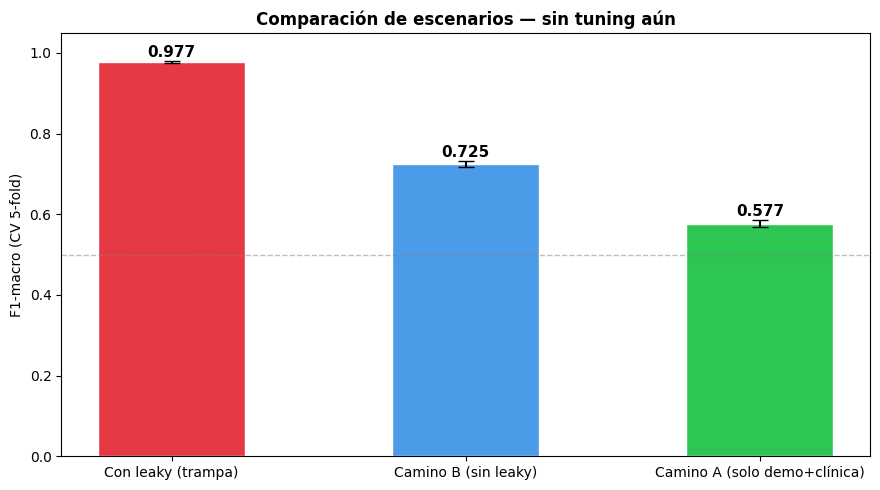

In [12]:
fig, ax = plt.subplots(figsize=(9, 5))

nombres  = list(resultados.keys())
medias   = [resultados[n].mean() for n in nombres]
stds     = [resultados[n].std()  for n in nombres]
colores  = ['#E63946', '#4C9BE8', '#2DC653']

bars = ax.bar(nombres, medias, yerr=stds, capsize=6,
              color=colores, edgecolor='white', width=0.5)

ax.set_ylim(0, 1.05)
ax.set_ylabel('F1-macro (CV 5-fold)')
ax.set_title('Comparación de escenarios — sin tuning aún', fontweight='bold')
ax.axhline(0.5, color='gray', ls='--', lw=1, alpha=0.5, label='Referencia (0.5)')

for bar, media, std in zip(bars, medias, stds):
    ax.text(bar.get_x() + bar.get_width()/2, media + std + 0.01,
            f'{media:.3f}', ha='center', fontweight='bold', fontsize=11)

plt.tight_layout()
plt.savefig('../assets/14_scenario_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

### 5.2 F1 por clase según escenario

El F1-macro agrega en un solo número, pero oculta qué clases específicas se benefician o perjudican con cada escenario. Esta tabla desagregada es clave para la decisión final, especialmente para `urge` y `stress`, las clases más difíciles.

In [13]:
from sklearn.metrics import f1_score

print(f"{'Clase':<10}", end="")
for nombre in escenarios:
    print(f"  {nombre[:18]:<18}", end="")
print()
print("-" * 70)

for i, cls in enumerate(CLASS_ORDER):
    print(f"{cls:<10}", end="")
    for nombre, X_esc in escenarios.items():
        m = xgb.XGBClassifier(
            objective='multi:softprob', num_class=4,
            eval_metric='mlogloss', use_label_encoder=False,
            random_state=42, n_jobs=-1
        )
        m.fit(X_esc, y_train_enc, verbose=False)
        y_p = m.predict(X_test[X_esc.columns])
        f1_cls = f1_score(y_test_enc, y_p, average=None)[i]
        print(f"  {f1_cls:.3f}              ", end="")
    print()

Clase       Con leaky (trampa)  Camino B (sin leak  Camino A (solo dem
----------------------------------------------------------------------
mixed       0.959                0.503                0.323              
none        0.951                0.812                0.693              
stress      0.950                0.340                0.258              
urge        0.919                0.176                0.164              


---
## Sección 6 — Decisión: Camino B

### Justificación

Los resultados muestran que la diferencia entre Camino A y Camino B en `urge` es mínima (~0.01), mientras que en `mixed` y `none` el Camino B aporta una mejora significativa. Los síntomas indirectos (`ui_frecuencia`, `ui_molestia_percibida`, `ui_impacto_actividades`) capturan información de **severidad** que el modelo puede usar para discriminar entre tipos sin revelar el tipo directamente.

**El modelo final se entrenará con el Camino B:** sin las variables `ui_esfuerzo_presente` y `ui_urgencia_presente`, pero conservando los síntomas indirectos. Esta elección es clínicamente interpretable y académicamente justificable.

### Próximo paso

El notebook `04_xgboost.ipynb` toma el Camino B y aplica optimización de hiperparámetros con Optuna, con la restricción de que el gap entre F1 de entrenamiento y validación no supere el 5%.